In [153]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
from pathlib import Path 
import glob, os
import numpy as np


In [154]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_vanhateren_raw(path, dtype=np.float32):
    """
    Load Van Hateren .iml or .imc binary image as raw linear luminance.
    """
    path = Path(path)
    raw = np.fromfile(path, dtype=">u2")  # big-endian uint16

    if raw.size == 1024 * 1536:
        img = raw.reshape((1024, 1536))

    elif raw.size == 768 * 1024:
        img = raw.reshape((768, 1024))

    else:
        raise ValueError(
            f"Unexpected size for {path.name}: {raw.size} uint16 values"
        )

    return img.astype(dtype)


def scale_luminance(img, percentile_scale=99, clip=True, eps=1e-8):
    """
    Scale image for training after filtering.
    """
    img = img.astype(np.float32)

    if percentile_scale is not None:
        scale = np.percentile(img, percentile_scale)
        img = img / (scale + eps)

    if clip:
        img = np.clip(img, 0, 1)

    return img.astype(np.float32)


In [155]:
dpp = 1 / 60
n_images = 300

data_path = Path("vanhateren_iml/")
iml_files = np.array(sorted(data_path.glob("*.iml")), dtype=object)

def image_metrics(path):
    img = load_vanhateren_raw(path)

    mean = img.mean()
    std = img.std()
    cv = std / (mean + 1e-8)

    # optional robust contrast
    p1, p99 = np.percentile(img, [1, 99])
    robust_range = (p99 - p1) / (mean + 1e-8)

    return mean, std, cv, robust_range

metrics = np.array([
    image_metrics(f)
    for f in iml_files
])

raw_mean = metrics[:, 0]
raw_std = metrics[:, 1]
raw_cv = metrics[:, 2]
robust_range = metrics[:, 3]

In [156]:
mean_low_q = 0
cv_low_q = 0
cv_high_q = 100

mean_thresh = np.percentile(raw_mean, mean_low_q)
cv_low_thresh = np.percentile(raw_cv, cv_low_q)
cv_high_thresh = np.percentile(raw_cv, cv_high_q)

valid_mask = (
    (raw_mean >= mean_thresh)
    & (raw_cv >= cv_low_thresh)
    & (raw_cv <= cv_high_thresh)
)

valid_files = np.array(iml_files, dtype=object)[valid_mask]
valid_original_indices = np.flatnonzero(valid_mask)

print(f"Mean threshold: {mean_thresh:.2f}")
print(f"CV low threshold: {cv_low_thresh:.4f}")
print(f"CV high threshold: {cv_high_thresh:.4f}")
print(f"Kept {valid_mask.sum()} / {len(valid_mask)} images")

Mean threshold: 173.84
CV low threshold: 0.1367
CV high threshold: 4.3622
Kept 4167 / 4167 images


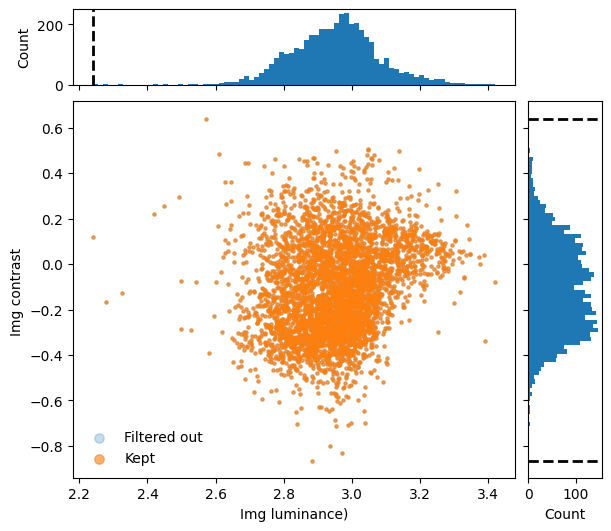

In [157]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

x = np.log10(raw_mean)
y = np.log10(raw_cv)

x_thresh = np.log10(mean_thresh)
y_low_thresh = np.log10(cv_low_thresh)
y_high_thresh = np.log10(cv_high_thresh)

fig = plt.figure(figsize=(5 * 1.2, 4 * 1.3), constrained_layout=True)

spec2 = gridspec.GridSpec(
    ncols=2,
    nrows=2,
    figure=fig,
    width_ratios=[6, 1],
    height_ratios=[1, 5],
)

ax1 = fig.add_subplot(spec2[0, 0])
ax3 = fig.add_subplot(spec2[1, 0], sharex=ax1)
ax2 = fig.add_subplot(spec2[1, 1], sharey=ax3)  # important fix

# Top histogram: mean luminance
ax1.hist(x, bins=80)
ax1.axvline(x_thresh, linestyle="--", c="k", linewidth=2)
ax1.tick_params(labelbottom=False)
ax1.set_ylabel("Count")

# Main scatter
ax3.scatter(x, y, s=5, alpha=0.25, label="Filtered out")
ax3.scatter(x[valid_mask], y[valid_mask], s=5, alpha=0.6, label="Kept")

# ax3.axvline(x_thresh, linestyle="--", c="k", linewidth=2)
# ax3.axhline(y_low_thresh, linestyle="--", c="k", linewidth=2)
# ax3.axhline(y_high_thresh, linestyle="--", c="k", linewidth=2)

ax3.set_xlabel("Img luminance)")
ax3.set_ylabel("Img contrast ")
# ax3.set_title("Kept vs filtered")
ax3.legend(frameon=False, markerscale=3)

# Right histogram: contrast
ax2.hist(y, orientation="horizontal", bins=80)
ax2.axhline(y_low_thresh, linestyle="--", c="k", linewidth=2)
ax2.axhline(y_high_thresh, linestyle="--", c="k", linewidth=2)

ax2.tick_params(labelleft=False)
ax2.set_xlabel("Count")
# ax2.set_title("Contrast")

plt.show()

In [168]:
from scipy.stats import spearmanr

spearman_r, spearman_p = spearmanr(x, y)

print(f"Spearman corr: {spearman_r:.3f}")
print(f"p-value: {spearman_p:.3e}")

Spearman corr: 0.208
p-value: 7.699e-42


In [169]:
n_images = 300
rng = np.random.default_rng(0)

if len(valid_files) < n_images:
    raise ValueError(
        f"Only {len(valid_files)} valid images after filtering, "
        f"but n_images={n_images}."
    )

local_selected = rng.choice(len(valid_files), size=n_images, replace=False)

selected_files = valid_files[local_selected]
image_indices = valid_original_indices[local_selected]

In [170]:
images = np.stack(
    [
        scale_luminance(
            load_vanhateren_raw(f),
            percentile_scale=99,
            clip=True,
        )
        for f in selected_files
    ],
    axis=0,
)

mean_lum_per_image = images.mean(axis=(1, 2), keepdims=True)
images_contrast = (images - mean_lum_per_image) / (mean_lum_per_image + 1e-8)

In [171]:

print(
    "Contrast images:",
    images_contrast.shape,
    images_contrast.min(),
    images_contrast.max(),
    images_contrast.mean(),
)

Contrast images: (300, 1024, 1536) -1.0 21.493366 -2.4504132e-09


In [172]:
ensemble_hist = images_contrast.ravel()

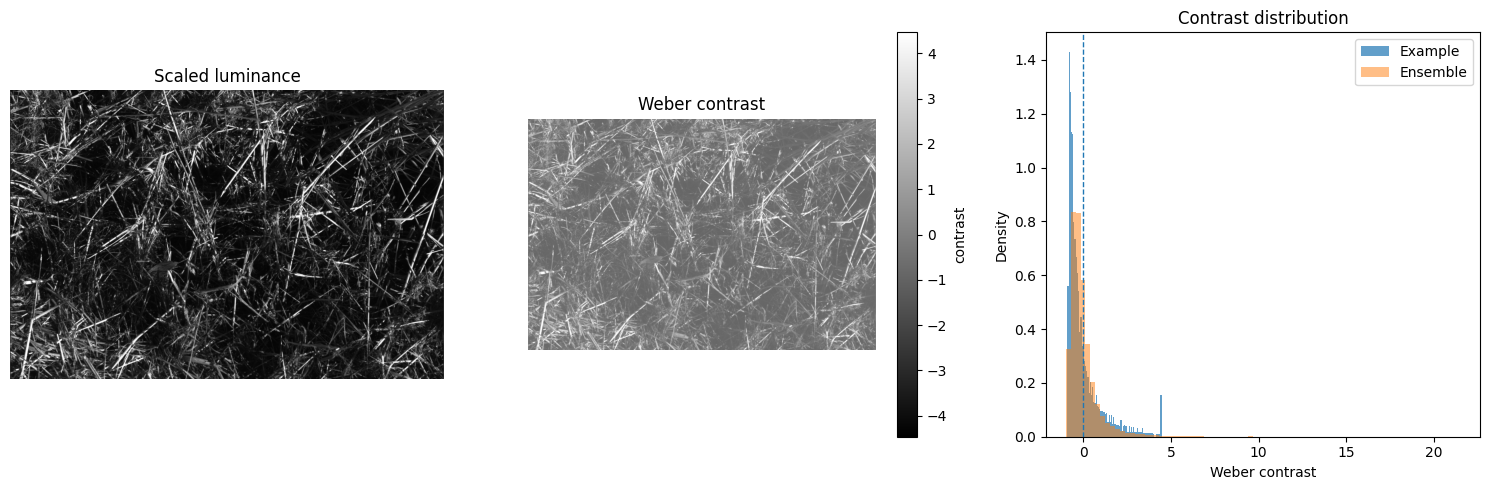

In [173]:
idx = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(images[idx], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Scaled luminance")
axes[0].axis("off")

v = np.percentile(np.abs(images_contrast[idx]), 99)
im = axes[1].imshow(
    images_contrast[idx],
    cmap="gray",
    vmin=-v,
    vmax=v,
)
axes[1].set_title("Weber contrast")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="contrast")

axes[2].hist(images_contrast[idx].ravel(), bins=80, density=True, alpha=0.7, label="Example")
axes[2].hist(ensemble_hist, bins=80, density=True, alpha=0.5, label="Ensemble")
axes[2].axvline(0, linestyle="--", linewidth=1)
axes[2].set_title("Contrast distribution")
axes[2].set_xlabel("Weber contrast")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.show()

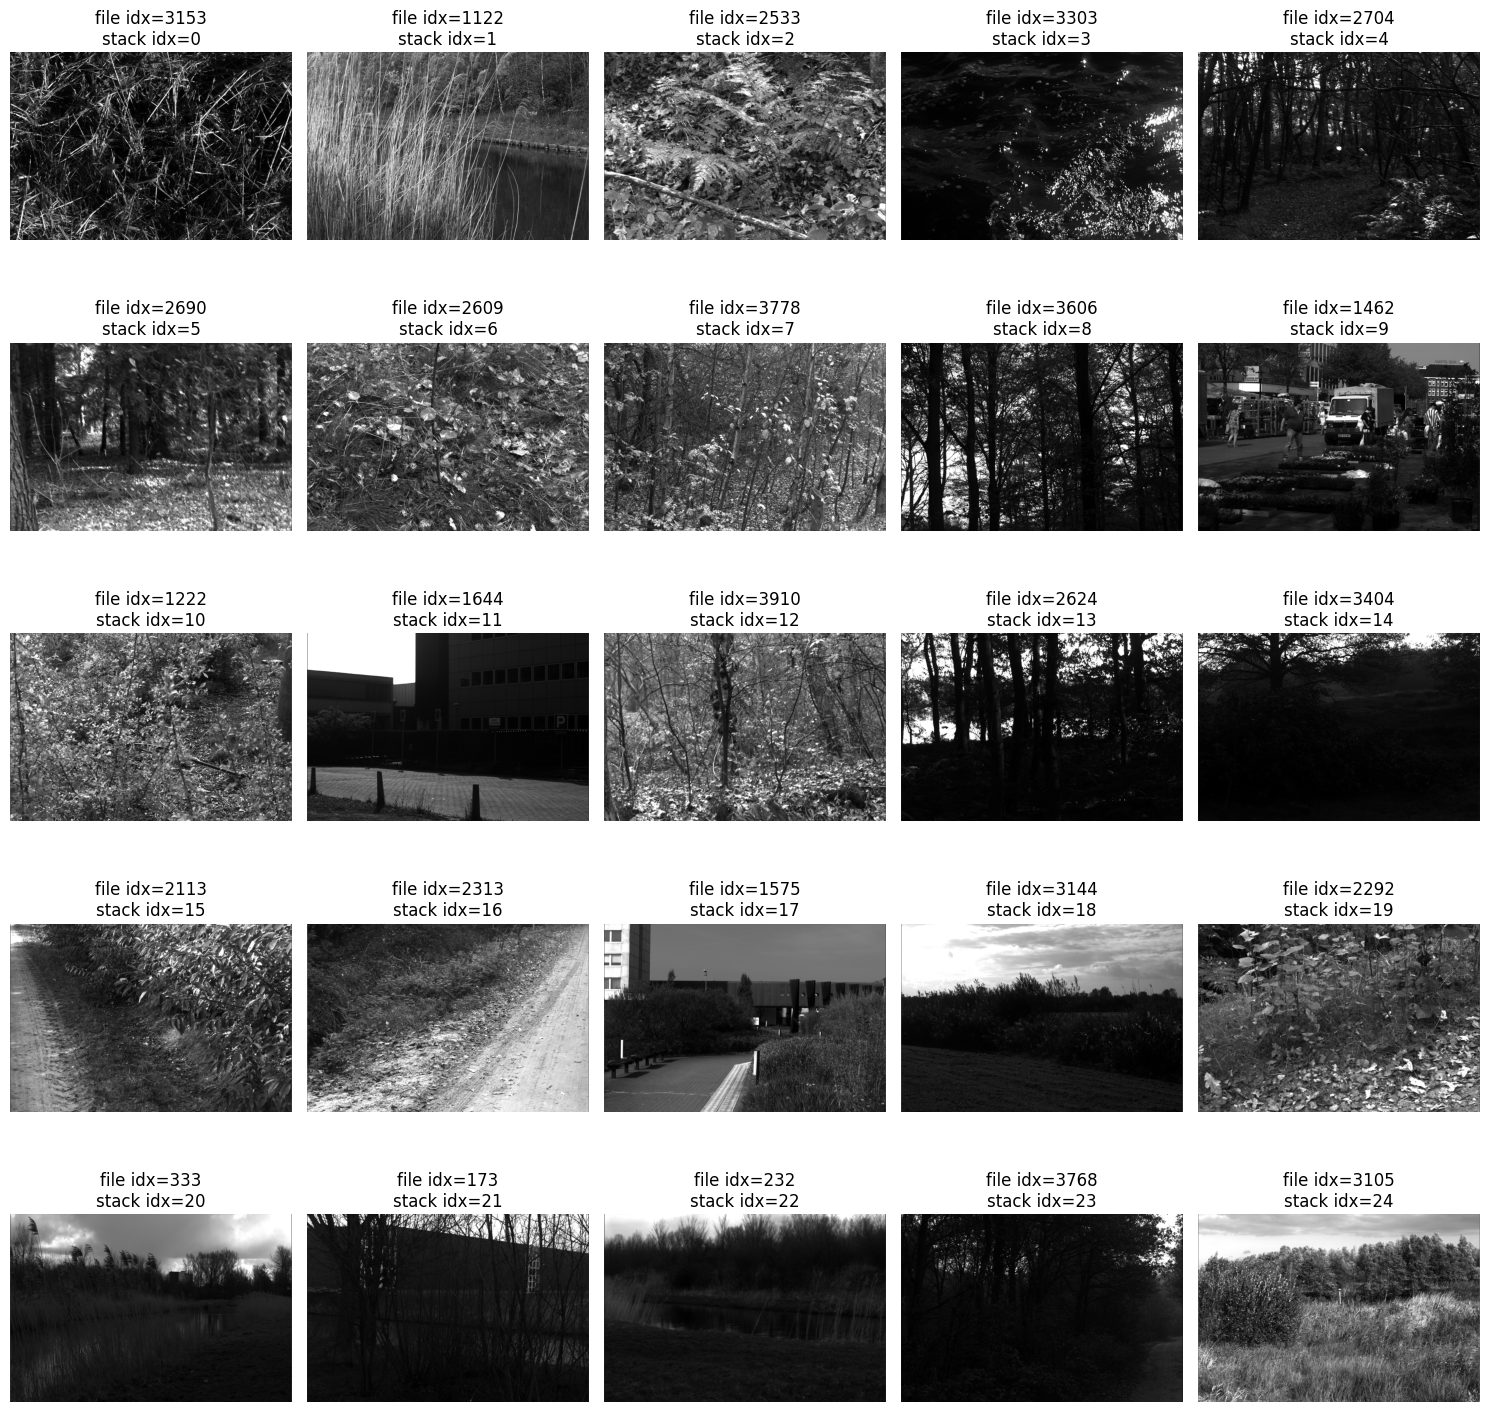

In [174]:
n_rows = 5
n_cols = 5
n_samples = n_rows * n_cols

fig, axes = plt.subplots(
    n_rows, 
    n_cols, 
    figsize=(3 * n_cols, 3 * n_rows)
)

axes = np.atleast_2d(axes)

for idx, ax in enumerate(axes.flat[:n_samples]):
    original_idx = image_indices[idx]

    img = images[idx, :, :]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"file idx={original_idx}\nstack idx={idx}")
    ax.axis("off")

for ax in axes.flat[n_samples:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

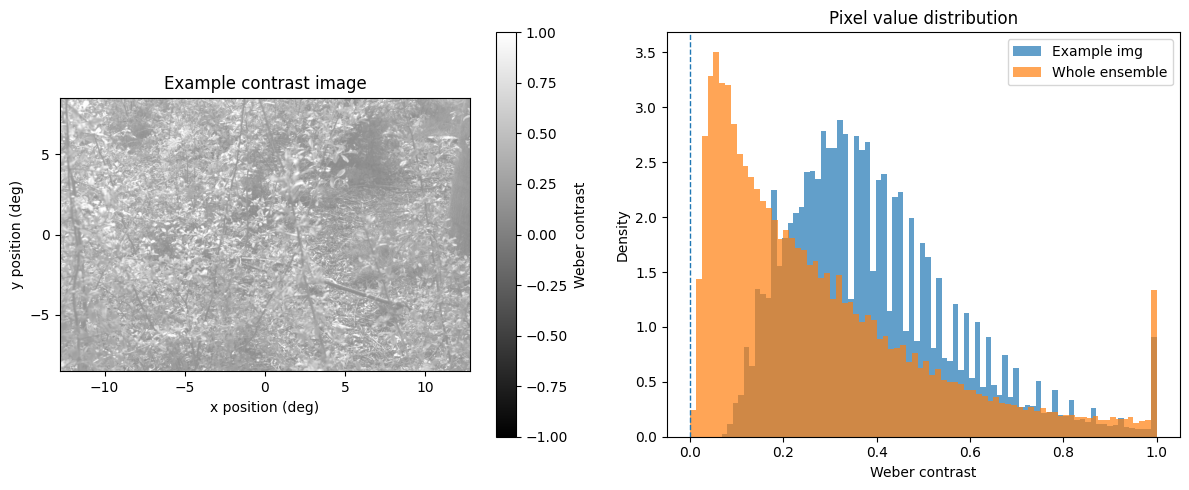

In [175]:
def imshow_deg(ax, img, dpp=1/60, center=True, cmap="gray", symmetric=True):
    """
    Plot image with x/y axes in visual degrees.

    Parameters
    ----------
    img : array, shape (H, W)
    dpp : float
        Degrees per pixel. For full-res Van Hateren .iml, dpp = 1/60.
    center : bool
        If True, coordinate origin is image center.
    symmetric : bool
        If True, use symmetric contrast limits around 0.
    """
    H, W = img.shape

    if center:
        x_min = -0.5 * W * dpp
        x_max =  0.5 * W * dpp
        y_min = -0.5 * H * dpp
        y_max =  0.5 * H * dpp
    else:
        x_min = 0
        x_max = W * dpp
        y_min = 0
        y_max = H * dpp

    if symmetric:
        v = np.percentile(np.abs(img), 99)
        vmin, vmax = -v, v
    else:
        vmin, vmax = np.percentile(img, [1, 99])

    im = ax.imshow(
        img,
        cmap=cmap,
        extent=[x_min, x_max, y_min, y_max],
        origin="upper",
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    ax.set_xlabel("x position (deg)")
    ax.set_ylabel("y position (deg)")

    return im

idx = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = imshow_deg(
    axes[0],
    images[idx],
    dpp=1/60,
    center=True,
    cmap="gray",
    symmetric=True,
)

axes[0].set_title("Example contrast image")
axes[0].set_yticks([-5,0,5])
plt.colorbar(im, ax=axes[0], label="Weber contrast")

axes[1].hist(
    images[idx].ravel(),
    bins=80,
    density=True,
    alpha=0.7,
    label="Example img",
)

axes[1].hist(
    images.ravel(),
    bins=80,
    density=True,
    alpha=0.7,
    label="Whole ensemble",
)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_title("Pixel value distribution")
axes[1].set_xlabel("Weber contrast")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

## Velocity traces with degree resolution


In [166]:
from torch.utils.data import Dataset
from skimage.transform import resize
import torch
import numpy as np
import h5py

class CorrelationVelDataset(Dataset):
    def __init__(
        self,
        file, 
        screen_size=(600, 800),
        crop_hw = (400, 400),
        downsample_hw = (96, 96),
        frames_per_segment = 75,
        fps = 75,   
        gray_sec = 0.2, 
        gray_value = 0.5,
        samples_per_image = 6,
        vel_half_life_s = 0.2, ## Velocity trace params
        vel_std = (500, 500),
        vel_corr = 0.0,
        dpp = 1/60, 
        random_seed = 0,
        include_frozen=True,
        include_running=True,
        running_runs=None,
        normalize_images=True,
        movie_format="TCHW",
        dtype=torch.float32,
        ):
        
        self.file = file
        self.screen_size = screen_size
        self.crop_hw = crop_hw
        self.downsample_hw = downsample_hw
        self.frames_per_segment = frames_per_segment
        self.fps = fps
        self.gray_sec = gray_sec
        self.gray_frames = int(round(gray_sec * fps))
        self.gray_value = gray_value
        self.include_frozen = include_frozen
        self.include_running = include_running
        self.running_runs = running_runs
        self.normalize_images = normalize_images
        self.movie_format = movie_format
        self.dtype = dtype
        self.vel_half_life_s = vel_half_life_s
        self.vel_std = vel_std
        self.vel_corr = vel_corr
        
        self.random_seed = random_seed
        self.samples_per_image = samples_per_image
        
        self.dpp = float(dpp)              # degrees / source pixel
        self.ppd = 1.0 / self.dpp          # source pixels / degree

        self.screen_deg = (
            self.screen_size[0] * self.dpp,
            self.screen_size[1] * self.dpp,
        )

        self.crop_deg = (
            self.crop_hw[0] * self.dpp,
            self.crop_hw[1] * self.dpp,
        )

        self.output_dpp_yx = (
            self.crop_deg[0] / self.downsample_hw[0],
            self.crop_deg[1] / self.downsample_hw[1],
        )

        self.output_arcmin_per_px_yx = (
            self.output_dpp_yx[0] * 60,
            self.output_dpp_yx[1] * 60,
        )

        # Open once. This is convenient for now.
        # If dataloader workers later complain, we can switch to lazy file opening per worker.
        with h5py.File(self.file, "r") as h5:
            self.frozen_images = (
                np.array(h5["frozenImages"])
                .transpose((0, 2, 1))
                .astype(np.float32)
            )

            self.running_images = (
                np.array(h5["runningImages"])
                .transpose((0, 2, 1))
                .astype(np.float32)
            )

        self._h5 = None
        # Global normalization
        if self.normalize_images:
            global_min = min(self.frozen_images.min(), self.running_images.min())
            global_max = max(self.frozen_images.max(), self.running_images.max())
            scale = global_max - global_min + 1e-8

            self.frozen_images = (self.frozen_images - global_min) / scale
            self.running_images = (self.running_images - global_min) / scale

        # Build sample index
        self.index = []
        self._build_index()
    
    # ============================================================
    # Index building
    # ============================================================
    
    def _build_index(self):
        self.index = []
        sample_id = 0

        if self.include_frozen:
            n_images = self.frozen_images.shape[0]

            for image_idx in range(n_images):
                for rep in range(self.samples_per_image):
                    self.index.append({
                        "source": "frozen",
                        "image_idx": int(image_idx),
                        "rep": int(rep),
                        "sample_idx": sample_id,
                        "seed": self.random_seed + sample_id,
                    })
                    sample_id += 1

        if self.include_running:
            n_images = self.running_images.shape[0]

            for image_idx in range(n_images):
                for rep in range(self.samples_per_image):
                    self.index.append({
                        "source": "running",
                        "image_idx": int(image_idx),
                        "rep": int(rep),
                        "sample_idx": sample_id,
                        "seed": self.random_seed + sample_id,
                    })
                    sample_id += 1
    
    def print_geometry(self):
        print("=== Stimulus geometry ===")
        print(f"source dpp: {self.dpp:.6f} deg/source-px")
        print(f"source ppd: {self.ppd:.2f} source-px/deg")
        print()
        print(f"screen_size px: {self.screen_size}")
        print(f"screen_size deg: H={self.screen_deg[0]:.3f}, W={self.screen_deg[1]:.3f}")
        print()
        print(f"crop_hw px: {self.crop_hw}")
        print(f"crop_hw deg: H={self.crop_deg[0]:.3f}, W={self.crop_deg[1]:.3f}")
        print()
        print(f"downsample_hw: {self.downsample_hw}")
        print(
            "output dpp: "
            f"Y={self.output_dpp_yx[0]:.4f} deg/model-px, "
            f"X={self.output_dpp_yx[1]:.4f} deg/model-px"
        )
        print(
            "output arcmin/model-px: "
            f"Y={self.output_arcmin_per_px_yx[0]:.2f}, "
            f"X={self.output_arcmin_per_px_yx[1]:.2f}"
        )
        print()
        print(f"fps: {self.fps}")
        print(f"frames_per_segment: {self.frames_per_segment}")
        print(f"gray_frames: {self.gray_frames}")
        print(f"total frames returned: {self.frames_per_segment + self.gray_frames}")
        print(f"stim duration: {self.frames_per_segment / self.fps:.3f} s")
        print(f"gray duration: {self.gray_frames / self.fps:.3f} s")
        print()
        if np.isscalar(self.vel_std):
            vx = vy = float(self.vel_std)
        else:
            vx, vy = map(float, self.vel_std)

        print(f"vel_std px/s: X={vx:.2f}, Y={vy:.2f}")
        print(f"vel_std deg/s: X={vx * self.dpp:.3f}, Y={vy * self.dpp:.3f}")             
    # ============================================================
    # Velocity trace generation. 2D OU process with configurable correlation between x and y.
    # ============================================================
    
    def generate_velocity_trace_2d(
        self, seed):
        """
        Generate smooth 2D velocity traces vx(t), vy(t).

        Parameters
        ----------
        total_time_s : float
            Duration in seconds.
        sample_freq_hz : float
            Sampling frequency in Hz.
        half_life_s : float
            Temporal smoothness scale. Larger = smoother velocity.
        vel_std : float
            Stationary standard deviation of each velocity component,
            in pix/second.
        seed : int or None
            Random seed.

        Returns
        -------
        vel : ndarray, shape (T, 2)
            vel[:, 0] is vx, vel[:, 1] is vy.
        """

        T = self.frames_per_segment
        dt = 1.0 / self.fps

        tau = self.vel_half_life_s / np.log(2)
        alpha = np.exp(-dt / tau)
        
        # Allow scalar or tuple vel_std
        if np.isscalar(self.vel_std):
            sx = sy = float(self.vel_std)
        else:
            sx, sy = map(float, self.vel_std)

        rho = float(self.vel_corr)
        if not (-1.0 <= rho <= 1.0):
            raise ValueError("vel_corr must be between -1 and 1.")

        cov = np.array([
            [sx**2, rho * sx * sy],
            [rho * sx * sy, sy**2],
        ], dtype=np.float64)

        rng = np.random.default_rng(seed)
        
        noise = rng.multivariate_normal(
            mean=np.zeros(2),
            cov=cov,
            size=T,
        ).astype(np.float32)

        vel = np.zeros((T, 2), dtype=np.float32)

        for t in range(1, T):
            vel[t] = alpha * vel[t - 1] + np.sqrt(1 - alpha**2) * noise[t]

        pos = np.cumsum(vel, axis=0) * dt
        pos -= pos[0]

        # if clip_position_px is not None:
        #     pos = np.clip(
        #         pos,
        #         -float(clip_position_px),
        #         float(clip_position_px),
        #     )

        #     # Recompute velocity after clipping, so pos and vel remain consistent
        #     vel = compute_velocity(pos)

        return vel.astype(np.float32), pos.astype(np.float32)
    
    
    # ============================================================
    # Movie construction helpers
    # ============================================================
    def return_fix_movie(self, image_stack, fixations):
        screen_h, screen_w = self.screen_size
        n_images, img_h, img_w = image_stack.shape
        n_frames = fixations.shape[0]

        # movie = np.zeros((screen_h, screen_w, n_frames), dtype=np.float32)
        movie = np.full(
                (screen_h, screen_w, n_frames),
                self.gray_value,
                dtype=np.float32
            )
        for i in range(n_frames):
            img_idx = int(fixations[i, 0]) - 1  # MATLAB -> Python indexing
            trX = float(fixations[i, 1])
            trY = float(fixations[i, 2])

            if img_idx < 0 or img_idx >= n_images:
                continue

            xdst, ydst, xsrc, ysrc = self.get_ranges(
                trX, trY, screen_w, screen_h, img_w, img_h
            )

            patch = image_stack[img_idx][np.ix_(ysrc, xsrc)]
            movie[np.ix_(ydst, xdst, [i])] = patch[:, :, None]

        return movie

    # @staticmethod
    # def center_trace(fixations):
    #     pos = fixations[:, 1:3].astype(np.float32)
    #     pos = pos.copy()
    #     pos -= pos[0]
    #     return pos

    # def compute_velocity(self, pos):
    #     dt = 1.0 / self.fps
    #     vel = np.zeros_like(pos, dtype=np.float32)
    #     vel[1:] = np.diff(pos, axis=0) / dt
    #     return vel

    def center_crop_movie(self, movie):
        H, W, T = movie.shape
        crop_h, crop_w = self.crop_hw
        y0 = (H - crop_h) // 2
        x0 = (W - crop_w) // 2
        return movie[y0:y0 + crop_h, x0:x0 + crop_w, :]

    def add_gray_padding(self, movie):
        H, W, _ = movie.shape
        gray_block = np.full(
            (H, W, self.gray_frames),
            self.gray_value,
            dtype=movie.dtype
        )
        return np.concatenate([gray_block, movie], axis=2)

    def pad_position_trace(self, pos):
        pre = np.repeat(pos[:1], self.gray_frames, axis=0)
        return np.concatenate([pre, pos], axis=0)

    def pad_velocity_trace(self, vel):
        pre = np.zeros((self.gray_frames, vel.shape[1]), dtype=vel.dtype)
        return np.concatenate([pre, vel], axis=0)

    def pad_fixations_pre(self, fixations):
        pre = np.repeat(fixations[:1], self.gray_frames, axis=0)
        return np.concatenate([pre, fixations], axis=0)
    
    @staticmethod
    def downsample_movie(movie, target_hw=(96, 96)):
        H2, W2 = target_hw
        T = movie.shape[2]

        small = np.empty((H2, W2, T), dtype=np.float32)
        for t in range(T):
            small[:, :, t] = resize(
                movie[:, :, t],
                (H2, W2),
                order=1,
                anti_aliasing=True,
                preserve_range=True,
            ).astype(np.float32)

        return small

    # # ============================================================
    # # Segment selection
    # # ============================================================
    # def _get_segment_fixations(self, meta):
    #     start, end = meta["start"], meta["end"]

    #     if meta["source"] == "frozen":
    #         seg = self.frozen_fixations[start:end]
    #         image_stack = self.frozen_images
    #     else:
    #         seg = self.running_fixations[meta["run"]][start:end]
    #         image_stack = self.running_images

    #     return seg.astype(np.float32), image_stack

    # ============================================================
    # Geometry helper
    # ============================================================
    @staticmethod
    def get_ranges(trX, trY, screen_w, screen_h, img_w, img_h):
        ymin = (screen_h / 2) - trY + 1
        ymax = img_h + (screen_h / 2) - trY
        xmin = (screen_w / 2) - trX + 1
        xmax = img_w + (screen_w / 2) - trX

        ymin = max(1, ymin)
        xmin = max(1, xmin)
        ymax = min(screen_h, ymax)
        xmax = min(screen_w, xmax)

        rx = np.arange(1, screen_w + 1)
        ry = np.arange(1, screen_h + 1)

        rxuse = (rx >= xmin) & (rx <= xmax)
        ryuse = (ry >= ymin) & (ry <= ymax)

        xsrc = trX - (screen_w / 2) + rx[rxuse]
        ysrc = trY - (screen_h / 2) + ry[ryuse]

        xsrc = np.round(xsrc).astype(int) - 1
        ysrc = np.round(ysrc).astype(int) - 1

        xdst = np.where(rxuse)[0]
        ydst = np.where(ryuse)[0]

        return xdst, ydst, xsrc, ysrc
    # ============================================================
    # Dataset interface
    # ============================================================
    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        meta = self.index[idx]
        
        if meta["source"] == "frozen":
            image_stack = self.frozen_images
        else:
            image_stack = self.running_images
                
        image_idx = meta["image_idx"]
        seed = meta["seed"]
        # total_time_s = self.frames_per_segment / self.fps
        vel, pos = self.generate_velocity_trace_2d(seed=seed)
        
        vel = vel[:self.frames_per_segment]
        pos = pos[:self.frames_per_segment]
        
        img_h, img_w = image_stack.shape[1:]

        center_x = img_w / 2
        center_y = img_h / 2

        fixations = np.zeros((self.frames_per_segment, 3), dtype=np.float32)
        fixations[:, 0] = image_idx + 1  # MATLAB-style image index
        fixations[:, 1] = center_x + pos[:, 0]
        fixations[:, 2] = center_y + pos[:, 1]
        
        movie = self.return_fix_movie(image_stack, fixations)
        movie = self.center_crop_movie(movie)
        movie = self.downsample_movie(movie, target_hw=self.downsample_hw)
        movie = self.add_gray_padding(movie)
        pos =   self.pad_position_trace(pos)
        vel =   self.pad_velocity_trace(vel)
        fixations =   self.pad_fixations_pre(fixations)
        pos_deg = pos * self.dpp
        vel_deg_s = vel * self.dpp

        fixations_deg = fixations.copy()
        fixations_deg[:, 1] = (fixations[:, 1] - center_x) * self.dpp
        fixations_deg[:, 2] = (fixations[:, 2] - center_y) * self.dpp
        
        
        # convert movie format
        if self.movie_format == "TCHW":
            # (H, W, T) -> (T, H, W) -> (T, 1, H, W)
            movie = np.moveaxis(movie, 2, 0)
            movie = movie[:, None, :, :]
        elif self.movie_format == "HWT":
            pass
        else:
            raise ValueError(f"Unknown movie_format: {self.movie_format}")

        sample = {
            "movie": torch.from_numpy(movie).to(dtype=self.dtype),

            # original pixel-space outputs
            "fix_pos": torch.from_numpy(pos).to(dtype=self.dtype),
            "fix_vel": torch.from_numpy(vel).to(dtype=self.dtype),
            "scene_pos": torch.from_numpy(pos).to(dtype=self.dtype),
            "scene_vel": torch.from_numpy(vel).to(dtype=self.dtype),
            "fixations": torch.from_numpy(fixations).to(dtype=self.dtype),

            # degree-space outputs
            "fix_pos_deg": torch.from_numpy(pos_deg).to(dtype=self.dtype),
            "fix_vel_deg_s": torch.from_numpy(vel_deg_s).to(dtype=self.dtype),
            "scene_pos_deg": torch.from_numpy(pos_deg).to(dtype=self.dtype),
            "scene_vel_deg_s": torch.from_numpy(vel_deg_s).to(dtype=self.dtype),
            "fixations_deg": torch.from_numpy(fixations_deg).to(dtype=self.dtype),

            # geometry metadata
            "source_dpp": torch.tensor(self.dpp, dtype=self.dtype),
            "source_ppd": torch.tensor(self.ppd, dtype=self.dtype),
            "output_dpp_yx": torch.tensor(self.output_dpp_yx, dtype=self.dtype),
            "output_arcmin_per_px_yx": torch.tensor(self.output_arcmin_per_px_yx, dtype=self.dtype),

            "source": meta["source"],
            "image_idx": meta["image_idx"],
        }
        return sample
        

In [167]:
dataset = CorrelationVelDataset(
    file=h5_path,
    dpp=1/60,
    screen_size=(600, 800),
    crop_hw=(400, 400),
    downsample_hw=(96, 96),
    vel_std=(500, 500),
    normalize_images=False,
    gray_value=0.0,
)

dataset.print_geometry()

NameError: name 'h5_path' is not defined